# Bayesian Hyperparameter Tuning - Full 5-Phase Pipeline

**Strategy:**
- **Phases 1–4:** LinearSVC vs RandomForest, 3-fold stratified CV, with TF-IDF tuning and class_weight tuning
- **Phase 5:** HistGradientBoosting on ImpCHI + Stylometric features, **Leave-One-Out CV** on the ~240 Label 1+2 samples
- Each trial runs the **complete 5-phase pipeline end-to-end** on 3 folds, where Phase 5 uses LOOCV within each fold

### **Resume support:** if stopped early, re-running the notebook resumes from the last completed trial.

### **Checkpoint:** every 10 trials, `tuning/tuning_checkpoint.json` is overwritten with all results so far.

## 0. IMPORTS

In [10]:
import os, random, warnings, json, time
from datetime import timedelta
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.svm import LinearSVC
from sklearn.ensemble import (RandomForestClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

import optuna
from optuna.samplers import TPESampler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 359956
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)



## 1. DATA & PREPROCESSING

In [11]:
for res in ["punkt", "punkt_tab", "wordnet", "stopwords",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(res, quiet=True)

df = pd.read_csv("train.csv").dropna(subset=["TEXT", "LABEL"]).reset_index(drop=True)
print(f"Loaded {len(df)} rows")
print(df["LABEL"].value_counts().sort_index())

lemmatizer = WordNetLemmatizer()

def clean_text_none(text):
    text = str(text).lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["text_clean"] = df["TEXT"].apply(clean_text_none)
print("text cleaned")

# ── Stylometric features ──────────────────────────────────────
def extract_stylometric(text):
    text = str(text)
    sentences = sent_tokenize(text)
    n_sentences = max(len(sentences), 1)
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    words = word_tokenize(text)
    alpha_words = [w for w in words if w.isalpha()]
    n_words = max(len(alpha_words), 1)
    word_lengths = [len(w) for w in alpha_words] if alpha_words else [0]
    n_chars = max(len(text), 1)

    n_commas = text.count(",")
    n_periods = text.count(".")
    n_exclaim = text.count("!")
    n_question = text.count("?")
    n_semicolon = text.count(";")
    n_colon = text.count(":")
    n_dash = text.count("\u2014") + text.count("-")
    n_parens = text.count("(") + text.count(")")
    n_quotes = text.count('"') + text.count("'") + text.count("\u201c") + text.count("\u201d")

    try:
        tags = pos_tag(alpha_words[:200])
        tag_counts = Counter(t for _, t in tags)
        n_tagged = max(sum(tag_counts.values()), 1)
        pct_noun = (tag_counts.get("NN", 0) + tag_counts.get("NNS", 0) +
                    tag_counts.get("NNP", 0) + tag_counts.get("NNPS", 0)) / n_tagged
        pct_verb = (tag_counts.get("VB", 0) + tag_counts.get("VBD", 0) +
                    tag_counts.get("VBG", 0) + tag_counts.get("VBN", 0) +
                    tag_counts.get("VBP", 0) + tag_counts.get("VBZ", 0)) / n_tagged
        pct_adj = (tag_counts.get("JJ", 0) + tag_counts.get("JJR", 0) +
                   tag_counts.get("JJS", 0)) / n_tagged
        pct_adv = (tag_counts.get("RB", 0) + tag_counts.get("RBR", 0) +
                   tag_counts.get("RBS", 0)) / n_tagged
    except:
        pct_noun = pct_verb = pct_adj = pct_adv = 0.0

    unique_words = set(w.lower() for w in alpha_words)
    ttr = len(unique_words) / n_words
    pct_short = sum(1 for w in alpha_words if len(w) <= 3) / n_words
    pct_long = sum(1 for w in alpha_words if len(w) >= 8) / n_words

    return {
        "n_chars": n_chars, "n_words": n_words, "n_sentences": n_sentences,
        "avg_word_len": np.mean(word_lengths), "std_word_len": np.std(word_lengths),
        "avg_sent_len": np.mean(sent_lengths),
        "std_sent_len": np.std(sent_lengths) if len(sent_lengths) > 1 else 0,
        "max_sent_len": max(sent_lengths), "min_sent_len": min(sent_lengths),
        "comma_rate": n_commas / n_words, "period_rate": n_periods / n_words,
        "exclaim_rate": n_exclaim / n_words, "question_rate": n_question / n_words,
        "semicolon_rate": n_semicolon / n_words, "colon_rate": n_colon / n_words,
        "dash_rate": n_dash / n_words, "paren_rate": n_parens / n_words,
        "quote_rate": n_quotes / n_words,
        "total_punct_rate": (n_commas + n_periods + n_exclaim + n_question +
                             n_semicolon + n_colon) / n_words,
        "pct_noun": pct_noun, "pct_verb": pct_verb,
        "pct_adj": pct_adj, "pct_adv": pct_adv,
        "noun_verb_ratio": pct_noun / max(pct_verb, 0.001),
        "ttr": ttr, "pct_short_words": pct_short, "pct_long_words": pct_long,
        "words_per_sentence": n_words / n_sentences,
        "chars_per_word": n_chars / n_words,
    }

print("\nExtracting stylometric features")
stylo_df = pd.DataFrame(df["TEXT"].apply(extract_stylometric).tolist())
STYLO_ALL = stylo_df.values.astype(float)
print(f"Stylometric features: {STYLO_ALL.shape}")
print("Preprocessing done.\n")



Loaded 2400 rows
LABEL
0    1520
1      80
2     160
3      80
4     240
5     320
Name: count, dtype: int64
text cleaned

Extracting stylometric features
Stylometric features: (2400, 29)
Preprocessing done.



## 2. GLOBALS & FOLD INDICES

In [12]:
TEXTS = df["text_clean"].values
RAW_TEXTS = df["TEXT"].values
LABELS = df["LABEL"].values

# 3-fold for end-to-end pipeline
N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLD_INDICES = list(skf.split(TEXTS, LABELS))

# Pre-compute label 1+2 indices for LOOCV
MASK_12_GLOBAL = np.isin(LABELS, [1, 2])
IDX_12_GLOBAL = np.where(MASK_12_GLOBAL)[0]
print(f"Label 1+2 samples: {len(IDX_12_GLOBAL)} (for LOOCV)")

N_TRIALS = 10

# Checkpoint paths
TUNING_DIR = Path("tuning")
TUNING_DIR.mkdir(exist_ok=True)
CHECKPOINT_FILE = TUNING_DIR / "tuning_checkpoint.json"
RESULTS_FILE = TUNING_DIR / "tuning_results.json"
TOP5_FILE = TUNING_DIR / "tuning_top5.json"



Label 1+2 samples: 240 (for LOOCV)


## 3. FEATURE BUILDERS

In [13]:
def build_impchi(X_tr_text, X_other_text, y_tr, k_per_class,
                 impchi_max_feat=15000, impchi_ngram=(1, 2), impchi_min_df=2):
    """ImpCHI: top-K features per class via Chi-squared."""
    tfidf = TfidfVectorizer(max_features=impchi_max_feat, ngram_range=impchi_ngram,
                            sublinear_tf=True, min_df=impchi_min_df,
                            strip_accents="unicode", analyzer="word")
    X_tr_full = tfidf.fit_transform(X_tr_text)
    X_other_full = tfidf.transform(X_other_text)

    classes = np.unique(y_tr)
    selected_indices = set()
    for cls in classes:
        y_binary = (y_tr == cls).astype(int)
        scores, _ = chi2(X_tr_full, y_binary)
        top_k_idx = np.argsort(scores)[-k_per_class:]
        selected_indices.update(top_k_idx)

    selected = sorted(selected_indices)
    return X_tr_full[:, selected], X_other_full[:, selected]


def build_stylo(tr_idx, val_idx):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(STYLO_ALL[tr_idx])
    X_val = scaler.transform(STYLO_ALL[val_idx])
    return csr_matrix(X_tr), csr_matrix(X_val), scaler


def run_loocv_phase5(global_idx_12, y_12, hgb_params, impchi_params):
    """
    Leave-One-Out CV on label 1+2 subset.
    Returns macro F1 over all 240 LOO predictions.
    """
    texts_12 = TEXTS[global_idx_12]
    n = len(global_idx_12)
    loo_preds = np.zeros(n, dtype=int)

    for i in range(n):
        tr_mask = np.ones(n, dtype=bool)
        tr_mask[i] = False

        tr_idx_local = np.where(tr_mask)[0]
        val_idx_local = i

        tr_global = global_idx_12[tr_idx_local]
        val_global = global_idx_12[[val_idx_local]]

        y_tr_loo = y_12[tr_idx_local]

        # ImpCHI
        X_tr_chi, X_val_chi = build_impchi(
            texts_12[tr_idx_local], texts_12[[val_idx_local]],
            y_tr_loo,
            k_per_class=impchi_params["k_per_class"],
            impchi_max_feat=impchi_params["max_features"],
            impchi_ngram=impchi_params["ngram_range"],
            impchi_min_df=impchi_params["min_df"]
        )

        # Stylo
        X_tr_sty, X_val_sty, _ = build_stylo(tr_global, val_global)

        # Concat → dense
        X_tr_p5 = hstack([X_tr_chi, X_tr_sty]).toarray()
        X_val_p5 = hstack([X_val_chi, X_val_sty]).toarray()

        m5 = HistGradientBoostingClassifier(
            max_iter=hgb_params["max_iter"],
            max_depth=hgb_params["max_depth"],
            learning_rate=hgb_params["learning_rate"],
            max_leaf_nodes=hgb_params["max_leaf_nodes"],
            min_samples_leaf=hgb_params["min_samples_leaf"],
            l2_regularization=hgb_params["l2_regularization"],
            class_weight=hgb_params["class_weight"],
            random_state=SEED
        )
        m5.fit(X_tr_p5, y_tr_loo)
        loo_preds[i] = m5.predict(X_val_p5)[0]

    return f1_score(y_12, loo_preds, average="macro")



## 4. OPTUNA OBJECTIVE

In [14]:
def objective(trial):
    # ══════════════════════════════════════════════════════════
    # A. PHASES 1–4: model choice + hyperparameters
    # ══════════════════════════════════════════════════════════
    p14_model = trial.suggest_categorical("p14_model", ["linearsvc", "random_forest"])
    p14_class_weight = trial.suggest_categorical("p14_class_weight", ["balanced", "none"])
    cw = "balanced" if p14_class_weight == "balanced" else None

    # TF-IDF
    tfidf_max_features = trial.suggest_int("tfidf_max_features", 3000, 50000, log=True)
    tfidf_ngram_max = trial.suggest_int("tfidf_ngram_max", 1, 3)
    tfidf_sublinear = trial.suggest_categorical("tfidf_sublinear", [True, False])
    tfidf_min_df = trial.suggest_int("tfidf_min_df", 1, 5)

    if p14_model == "linearsvc":
        svc_C = trial.suggest_float("svc_C", 0.05, 20.0, log=True)
    else:
        rf_n = trial.suggest_int("rf_n_estimators", 100, 500)
        rf_depth = trial.suggest_int("rf_max_depth", 5, 30)
        rf_min_split = trial.suggest_int("rf_min_samples_split", 2, 8)
        rf_min_leaf = trial.suggest_int("rf_min_samples_leaf", 1, 5)

    # ══════════════════════════════════════════════════════════
    # B. PHASE 5: HistGB + ImpCHI params
    # ══════════════════════════════════════════════════════════
    hgb_max_iter = trial.suggest_int("hgb_max_iter", 30, 200)
    hgb_max_depth = trial.suggest_int("hgb_max_depth", 3, 16)
    hgb_lr = trial.suggest_float("hgb_learning_rate", 0.01, 0.3, log=True)
    hgb_leaves = trial.suggest_int("hgb_max_leaf_nodes", 5, 31)
    hgb_min_leaf = trial.suggest_int("hgb_min_samples_leaf", 3, 20)
    hgb_l2 = trial.suggest_float("hgb_l2_regularization", 0.0, 10.0)
    hgb_cw = trial.suggest_categorical("hgb_class_weight", ["balanced", "none"])

    impchi_k = trial.suggest_int("impchi_k_per_class", 15, 80)
    impchi_max_feat = trial.suggest_int("impchi_max_features", 5000, 20000, log=True)
    impchi_ngram_max = trial.suggest_int("impchi_ngram_max", 1, 3)
    impchi_min_df = trial.suggest_int("impchi_min_df", 1, 5)

    hgb_params = {
        "max_iter": hgb_max_iter, "max_depth": hgb_max_depth,
        "learning_rate": hgb_lr, "max_leaf_nodes": hgb_leaves,
        "min_samples_leaf": hgb_min_leaf, "l2_regularization": hgb_l2,
        "class_weight": "balanced" if hgb_cw == "balanced" else None,
    }
    impchi_params = {
        "k_per_class": impchi_k, "max_features": impchi_max_feat,
        "ngram_range": (1, impchi_ngram_max), "min_df": impchi_min_df,
    }

    # ══════════════════════════════════════════════════════════
    # C. 3-FOLD CV - full 5-phase pipeline
    # ══════════════════════════════════════════════════════════
    fold_scores = []

    for train_idx, val_idx in FOLD_INDICES:
        X_tr_text = TEXTS[train_idx]
        X_val_text = TEXTS[val_idx]
        y_tr = LABELS[train_idx]
        y_val = LABELS[val_idx]

        # ── TF-IDF ────────────────────────────────────────────
        tfidf = TfidfVectorizer(
            max_features=tfidf_max_features,
            ngram_range=(1, tfidf_ngram_max),
            sublinear_tf=tfidf_sublinear,
            min_df=tfidf_min_df,
            strip_accents="unicode", analyzer="word"
        )
        X_tr_tfidf = tfidf.fit_transform(X_tr_text)
        X_val_tfidf = tfidf.transform(X_val_text)

        # ── Model builder ─────────────────────────────────────
        def make_model():
            if p14_model == "linearsvc":
                return LinearSVC(C=svc_C, max_iter=3000,
                                 class_weight=cw, random_state=SEED)
            else:
                return RandomForestClassifier(
                    n_estimators=rf_n, max_depth=rf_depth,
                    min_samples_split=rf_min_split,
                    min_samples_leaf=rf_min_leaf,
                    class_weight=cw, random_state=SEED, n_jobs=-1)

        final_pred = np.full(len(y_val), -1, dtype=int)
        val_pos = np.arange(len(y_val))

        # ── Phase 1: Human vs AI ──────────────────────────────
        m1 = make_model()
        m1.fit(X_tr_tfidf, (y_tr != 0).astype(int))
        pred_p1 = m1.predict(X_val_tfidf)
        final_pred[pred_p1 == 0] = 0
        ai_pos = val_pos[pred_p1 == 1]

        # ── Phase 2: Label 4 vs (1,2,3,5) ────────────────────
        ai_mask_tr = y_tr != 0
        m2 = make_model()
        m2.fit(X_tr_tfidf[ai_mask_tr], (y_tr[ai_mask_tr] == 4).astype(int))
        if len(ai_pos) > 0:
            pred_p2 = m2.predict(X_val_tfidf[ai_pos])
            final_pred[ai_pos[pred_p2 == 1]] = 4
            remaining = ai_pos[pred_p2 == 0]
        else:
            remaining = np.array([], dtype=int)

        # ── Phase 3: Label 3 vs (1,2,5) ──────────────────────
        mask_1235 = np.isin(y_tr, [1, 2, 3, 5])
        m3 = make_model()
        m3.fit(X_tr_tfidf[mask_1235], (y_tr[mask_1235] == 3).astype(int))
        if len(remaining) > 0:
            pred_p3 = m3.predict(X_val_tfidf[remaining])
            final_pred[remaining[pred_p3 == 1]] = 3
            remaining = remaining[pred_p3 == 0]

        # ── Phase 4: Label 5 vs (1,2) ────────────────────────
        mask_125 = np.isin(y_tr, [1, 2, 5])
        m4 = make_model()
        m4.fit(X_tr_tfidf[mask_125], (y_tr[mask_125] == 5).astype(int))
        if len(remaining) > 0:
            pred_p4 = m4.predict(X_val_tfidf[remaining])
            final_pred[remaining[pred_p4 == 1]] = 5
            remaining = remaining[pred_p4 == 0]

        # ── Phase 5: LOOCV on label 1+2 within this fold ─────
        # Get global indices of label 1+2 in training set
        tr_global_12 = train_idx[np.isin(y_tr, [1, 2])]
        y_tr_12 = LABELS[tr_global_12]

        # Run LOOCV on the training label 1+2 subset
        f1_p5_loo = run_loocv_phase5(
            tr_global_12, y_tr_12, hgb_params, impchi_params
        )

        # For end-to-end F1: train Phase 5 on full training 1+2,
        # predict on val samples reaching phase 5
        if len(remaining) > 0:
            val_global_p5 = val_idx[remaining]
            y_val_p5 = y_val[remaining]

            X_tr_chi, X_val_chi = build_impchi(
                TEXTS[tr_global_12], TEXTS[val_global_p5],
                y_tr_12,
                k_per_class=impchi_params["k_per_class"],
                impchi_max_feat=impchi_params["max_features"],
                impchi_ngram=impchi_params["ngram_range"],
                impchi_min_df=impchi_params["min_df"]
            )
            X_tr_sty, X_val_sty, _ = build_stylo(tr_global_12, val_global_p5)

            X_tr_p5 = hstack([X_tr_chi, X_tr_sty]).toarray()
            X_val_p5 = hstack([X_val_chi, X_val_sty]).toarray()

            m5 = HistGradientBoostingClassifier(
                **hgb_params, random_state=SEED
            )
            m5.fit(X_tr_p5, y_tr_12)
            pred_p5 = m5.predict(X_val_p5)
            final_pred[remaining] = pred_p5

        # Fallback
        if (final_pred == -1).any():
            final_pred[final_pred == -1] = 1

        fold_scores.append(f1_score(y_val, final_pred, average="macro"))

    # Store LOOCV F1 as user attribute for analysis
    trial.set_user_attr("f1_p5_loocv", f1_p5_loo)

    return float(np.mean(fold_scores))



## 5. CHECKPOINT / RESUME LOGIC

In [ ]:
def save_checkpoint(study):
    #Save all completed trials to checkpoint JSON
    records = []
    for t in study.trials:
        if t.state == optuna.trial.TrialState.COMPLETE:
            records.append({
                "number": t.number,
                "f1_mean": t.value,
                "f1_p5_loocv": t.user_attrs.get("f1_p5_loocv"),
                "params": t.params,
                "duration_s": round(t.duration.total_seconds(), 1) if t.duration else None,
            })
    records.sort(key=lambda x: x["f1_mean"], reverse=True)
    with open(CHECKPOINT_FILE, "w") as fp:
        json.dump(records, fp, indent=2, default=str)
    return len(records)


def load_completed_count():
    #Count how many trials were already completed (for resume)
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, "r") as fp:
            data = json.load(fp)
        return len(data)
    return 0


## 6. RUN OPTUNA (with resume)

In [16]:
already_done = load_completed_count()
remaining_trials = max(0, N_TRIALS - already_done)

print(f"Target: {N_TRIALS} trials")
print(f"Already completed: {already_done}")
print(f"Remaining: {remaining_trials}")

if remaining_trials == 0:
    print("All trials already completed! Skipping to results.")
else:
    # Create or load study (SQLite for persistence)
    storage_path = f"sqlite:///{TUNING_DIR}/optuna_study.db"
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        study_name="5phase_final",
        storage=storage_path,
        load_if_exists=True,
    )

    t0 = time.time()
    best_so_far = [0.0]

    # Initialize best from existing trials
    if len(study.trials) > 0:
        completed = [t for t in study.trials
                     if t.state == optuna.trial.TrialState.COMPLETE]
        if completed:
            best_so_far[0] = max(t.value for t in completed)

    def trial_callback(study, trial):
        elapsed = time.time() - t0
        n_done = trial.number + 1 - already_done
        if n_done <= 0:
            return
        avg = elapsed / n_done
        rem = avg * (remaining_trials - n_done)

        if trial.value and trial.value > best_so_far[0]:
            best_so_far[0] = trial.value

        if n_done % 10 == 0 or n_done == 1:
            print(
                f"  Trial {trial.number+1:>4d} (new #{n_done}/{remaining_trials})  "
                f"F1={trial.value:.4f}  "
                f"best={best_so_far[0]:.4f}  "
                f"| {timedelta(seconds=int(elapsed))} elapsed  "
                f"~{timedelta(seconds=int(rem))} remaining"
            )

        # Checkpoint every 10 new trials
        if n_done % 10 == 0:
            n_saved = save_checkpoint(study)
            print(f"    [CHECKPOINT] {n_saved} trials → {CHECKPOINT_FILE}")

    print(f"\nStarting Optuna ({remaining_trials} trials)\n")
    study.optimize(objective, n_trials=remaining_trials, callbacks=[trial_callback])

    total_time = time.time() - t0
    print(f"\nFinished! {remaining_trials} new trials in {timedelta(seconds=int(total_time))}")
    print(f"Best F1-macro: {study.best_value:.4f}")

    # Final save
    save_checkpoint(study)

Target: 10 trials
Already completed: 10
Remaining: 0
All trials already completed! Skipping to results.


## 7. SAVE FINAL RESULTS

In [17]:
# Also copy checkpoint to results (same data, different name for clarity)
if CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)
    with open(RESULTS_FILE, "w") as fp:
        json.dump(all_results, fp, indent=2, default=str)
    print(f"Saved {len(all_results)} trials → {RESULTS_FILE}")
else:
    print("No checkpoint file found. Run the tuning first.")
    all_results = []



Saved 10 trials → tuning\tuning_results.json


## 8. TOP 5 CONFIGURATIONS 
Loads from checkpoint - works even if stopped early

In [18]:
if CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)
else:
    all_results = []

print(f"\nLoaded {len(all_results)} trials from checkpoint.\n")
print("=" * 90)
print("  TOP 5 CONFIGURATIONS (by 3-fold end-to-end macro F1)")
print("=" * 90)

top5 = []
for rank, r in enumerate(all_results[:5], 1):
    params = r["params"]
    print(f"\n  ── #{rank}  Trial {r['number']}  F1 = {r['f1_mean']:.4f}  "
          f"(P5 LOOCV: {r.get('f1_p5_loocv', 'N/A')}) ──")

    print(f"  [Phases 1-4] {params['p14_model']}  class_weight={params['p14_class_weight']}")
    print(f"    TF-IDF: max_features={params['tfidf_max_features']}, "
          f"ngram=(1,{params['tfidf_ngram_max']}), "
          f"sublinear={params['tfidf_sublinear']}, "
          f"min_df={params['tfidf_min_df']}")

    if params["p14_model"] == "linearsvc":
        print(f"    C={params.get('svc_C', 'N/A')}")
    else:
        print(f"    n_estimators={params.get('rf_n_estimators')}, "
              f"max_depth={params.get('rf_max_depth')}, "
              f"min_split={params.get('rf_min_samples_split')}, "
              f"min_leaf={params.get('rf_min_samples_leaf')}")

    print(f"  [Phase 5] HistGB + ImpCHI+Stylo  class_weight={params.get('hgb_class_weight')}")
    for k in ["hgb_max_iter", "hgb_max_depth", "hgb_learning_rate",
              "hgb_max_leaf_nodes", "hgb_min_samples_leaf", "hgb_l2_regularization",
              "impchi_k_per_class", "impchi_max_features", "impchi_ngram_max", "impchi_min_df"]:
        v = params.get(k)
        if v is not None:
            v_str = f"{v:.4f}" if isinstance(v, float) else str(v)
            print(f"    {k:<30s}: {v_str}")

    top5.append({
        "rank": rank,
        "trial": r["number"],
        "f1_mean_3fold": r["f1_mean"],
        "f1_p5_loocv": r.get("f1_p5_loocv"),
        "params": params,
    })

with open(TOP5_FILE, "w") as fp:
    json.dump(top5, fp, indent=2, default=str)
print(f"\nSaved: {TOP5_FILE}")




Loaded 10 trials from checkpoint.

  TOP 5 CONFIGURATIONS (by 3-fold end-to-end macro F1)

  ── #1  Trial 6  F1 = 0.9264  (P5 LOOCV: 0.7856757728253055) ──
  [Phases 1-4] linearsvc  class_weight=none
    TF-IDF: max_features=8884, ngram=(1,2), sublinear=False, min_df=1
    C=1.3950060773126143
  [Phase 5] HistGB + ImpCHI+Stylo  class_weight=none
    hgb_max_iter                  : 169
    hgb_max_depth                 : 14
    hgb_learning_rate             : 0.1369
    hgb_max_leaf_nodes            : 10
    hgb_min_samples_leaf          : 6
    hgb_l2_regularization         : 8.4008
    impchi_k_per_class            : 30
    impchi_max_features           : 9656
    impchi_ngram_max              : 3
    impchi_min_df                 : 2

  ── #2  Trial 9  F1 = 0.9121  (P5 LOOCV: 0.7877358490566038) ──
  [Phases 1-4] linearsvc  class_weight=balanced
    TF-IDF: max_features=3262, ngram=(1,2), sublinear=True, min_df=2
    C=0.5771617829228366
  [Phase 5] HistGB + ImpCHI+Stylo  class_weig

## 9. PLOTS 
From checkpoint - works even if stopped early

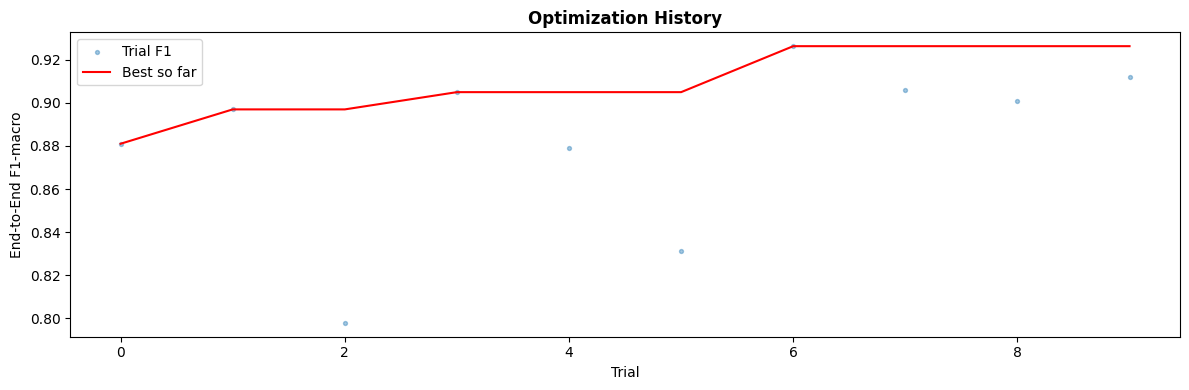

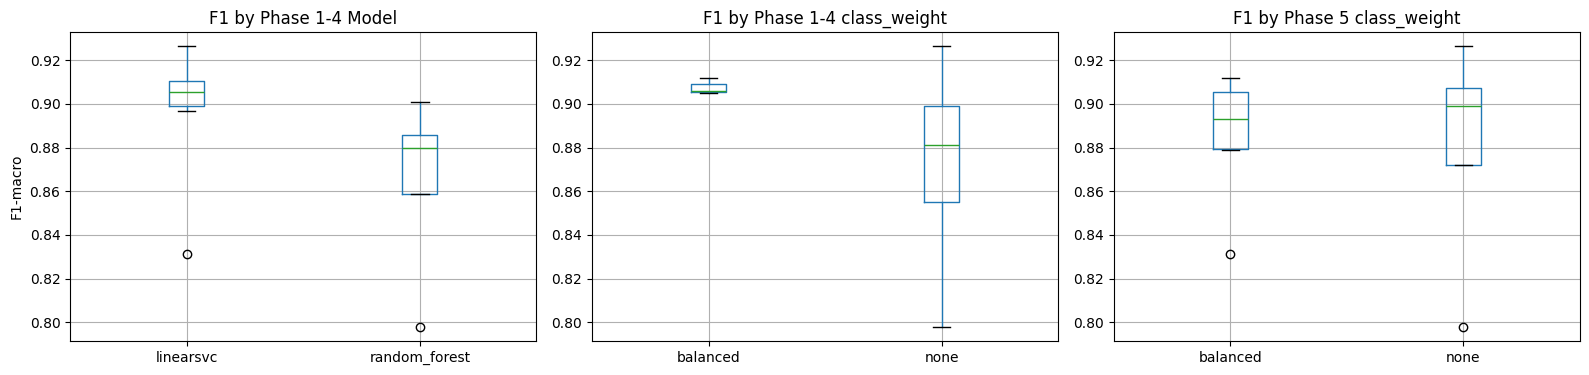

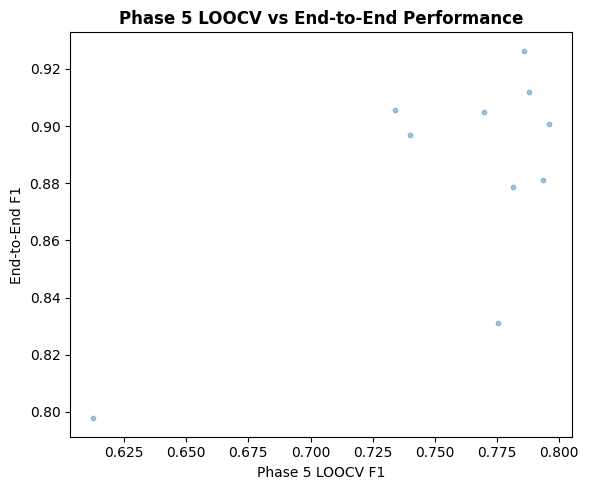

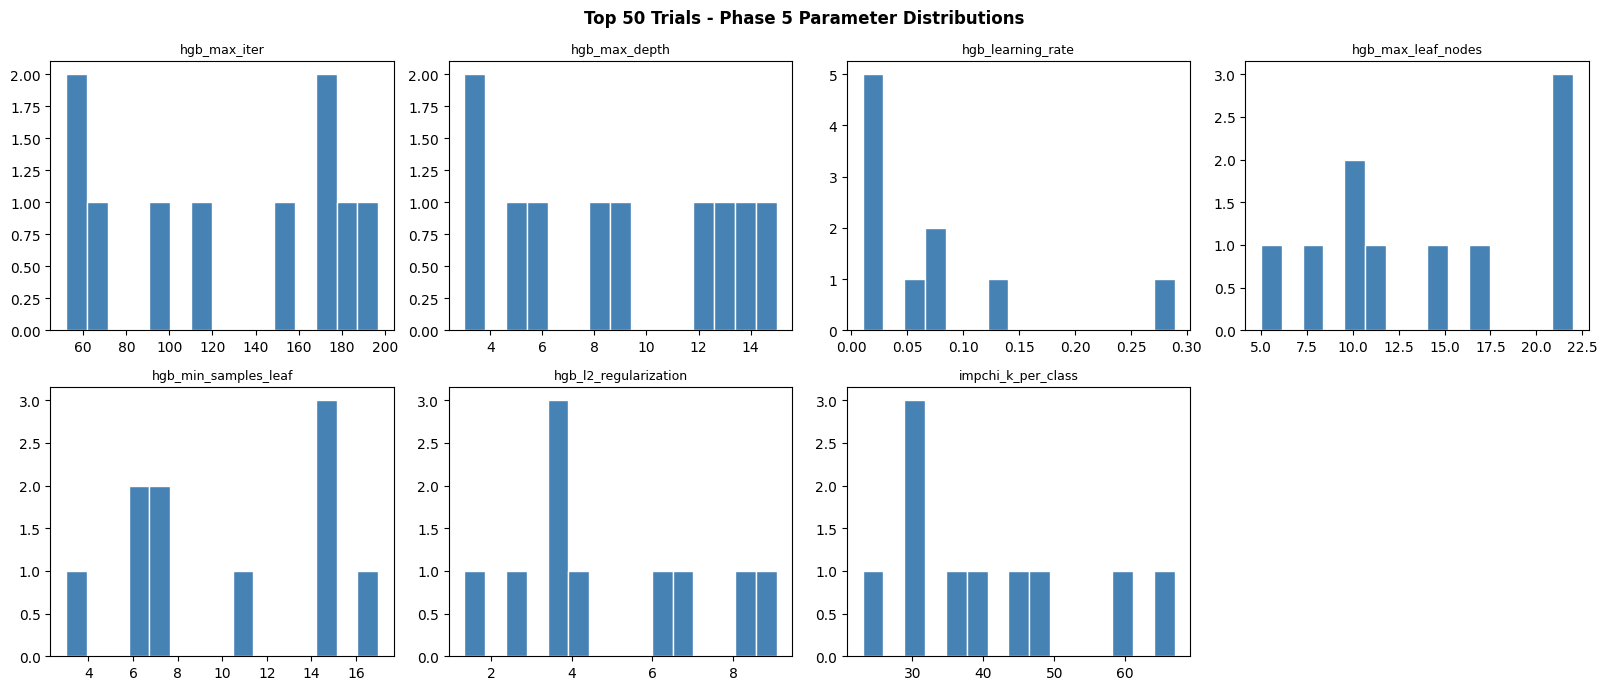

In [19]:
if not all_results:
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, "r") as fp:
            all_results = json.load(fp)

if all_results:
    df_r = pd.DataFrame(all_results)

    # ── Optimization history ──────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    trial_nums = [r["number"] for r in all_results]
    f1_vals = [r["f1_mean"] for r in all_results]
    # Sort by trial number for proper history
    order = np.argsort(trial_nums)
    t_sorted = np.array(trial_nums)[order]
    f1_sorted = np.array(f1_vals)[order]
    cummax = np.maximum.accumulate(f1_sorted)

    ax.scatter(t_sorted, f1_sorted, s=8, alpha=0.4, label="Trial F1")
    ax.plot(t_sorted, cummax, color="red", linewidth=1.5, label="Best so far")
    ax.set_xlabel("Trial")
    ax.set_ylabel("End-to-End F1-macro")
    ax.set_title("Optimization History", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Phase 1-4 model comparison ────────────────────────────
    df_r["p14_model"] = df_r["params"].apply(lambda p: p["p14_model"])
    df_r["p14_cw"] = df_r["params"].apply(lambda p: p["p14_class_weight"])
    df_r["hgb_cw"] = df_r["params"].apply(lambda p: p.get("hgb_class_weight", "N/A"))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Box 1: P14 model
    df_r.boxplot(column="f1_mean", by="p14_model", ax=axes[0])
    axes[0].set_title("F1 by Phase 1-4 Model")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("F1-macro")

    # Box 2: P14 class weight
    df_r.boxplot(column="f1_mean", by="p14_cw", ax=axes[1])
    axes[1].set_title("F1 by Phase 1-4 class_weight")
    axes[1].set_xlabel("")

    # Box 3: HGB class weight
    df_r.boxplot(column="f1_mean", by="hgb_cw", ax=axes[2])
    axes[2].set_title("F1 by Phase 5 class_weight")
    axes[2].set_xlabel("")

    plt.suptitle("")  # remove auto title
    plt.tight_layout()
    plt.show()

    # ── Phase 5 LOOCV F1 vs End-to-End F1 ────────────────────
    p5_vals = [r.get("f1_p5_loocv") for r in all_results]
    if any(v is not None for v in p5_vals):
        valid = [(r["f1_mean"], r["f1_p5_loocv"])
                 for r in all_results if r.get("f1_p5_loocv") is not None]
        e2e, p5 = zip(*valid)

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(p5, e2e, s=10, alpha=0.4)
        ax.set_xlabel("Phase 5 LOOCV F1")
        ax.set_ylabel("End-to-End F1")
        ax.set_title("Phase 5 LOOCV vs End-to-End Performance", fontweight="bold")
        plt.tight_layout()
        plt.show()

    # ── Top 50: HistGB parameter distributions ────────────────
    top50 = all_results[:50]
    hgb_keys = ["hgb_max_iter", "hgb_max_depth", "hgb_learning_rate",
                "hgb_max_leaf_nodes", "hgb_min_samples_leaf", "hgb_l2_regularization",
                "impchi_k_per_class"]

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.flatten()
    for idx, key in enumerate(hgb_keys):
        vals = [r["params"].get(key) for r in top50 if r["params"].get(key) is not None]
        if vals:
            axes[idx].hist(vals, bins=15, color="steelblue", edgecolor="white")
            axes[idx].set_title(key, fontsize=9)
    for j in range(len(hgb_keys), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Top 50 Trials - Phase 5 Parameter Distributions", fontweight="bold")
    plt.tight_layout()
    plt.show()

else:
    print("No results to plot. Run the tuning first.")



## 10. AGGREGATED ANALYSIS 
From checkpoint

In [20]:
if all_results:
    df_a = pd.DataFrame([{
        "f1": r["f1_mean"],
        "f1_p5": r.get("f1_p5_loocv"),
        "p14_model": r["params"]["p14_model"],
        "p14_cw": r["params"]["p14_class_weight"],
        "hgb_cw": r["params"].get("hgb_class_weight", "N/A"),
    } for r in all_results])

    print("\n" + "=" * 60)
    print("  AGGREGATED ANALYSIS")
    print("=" * 60)

    print("\n── Per Phase 1-4 model ──")
    print(df_a.groupby("p14_model")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n── Per Phase 1-4 class_weight ──")
    print(df_a.groupby("p14_cw")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n── Per Phase 5 class_weight ──")
    print(df_a.groupby("hgb_cw")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n── Per model × class_weight ──")
    print(df_a.groupby(["p14_model", "p14_cw"])["f1"].agg(["mean", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

print("\nTuning complete.")



  AGGREGATED ANALYSIS

── Per Phase 1-4 model ──
                 mean     std     max  count
p14_model                                   
linearsvc      0.8962  0.0334  0.9264      6
random_forest  0.8646  0.0456  0.9007      4

── Per Phase 1-4 class_weight ──
            mean     std     max  count
p14_cw                                 
none      0.8733  0.0442  0.9264      7
balanced  0.9076  0.0039  0.9121      3

── Per Phase 5 class_weight ──
            mean     std     max  count
hgb_cw                                 
none      0.8805  0.0567  0.9264      4
balanced  0.8856  0.0301  0.9121      6

── Per model × class_weight ──
                          mean     max  count
p14_model     p14_cw                         
linearsvc     none      0.8848  0.9264      3
              balanced  0.9076  0.9121      3
random_forest none      0.8646  0.9007      4

Tuning complete.
